# STAT301 Group Project: Team 23

## Final Report

**Dataset: Alzheimers Biomarkers**

**Group Number: 23**

**Group Name: no name**

**Group Members: Kenrick Tan, Aadetri Tawara, An Trinh, Adam Walmsley**

In [1]:
library(tidyverse)
library(readr)
library(broom)
library(dplyr)
library(caret)
library(pROC)
library(glmnet)
library(rsample)
library(ggplot2)
library(MASS)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'caret' was built under R version 4.5.3"
Loading required package: lattice


Attaching package: 'caret'


The following object is masked from 'package:purrr':

    lift


Warning message:
"package 'pROC' was built under R version 4.5.3"
Type 'citation("pROC")' for a citation.


Attaching package: 'pROC'


The following objects are masked from 'package:stats':

    cov, smooth, var


Warning message:
"package 'glmnet' was built under R version 4.5

## Introduction

#### Background and Motivation

Alzheimer’s disease is a progressive neurodegenerative disorder and the leading cause of dementia worldwide. Early and accurate diagnosis is critical for starting treatments that can significantly slow the progression of symptoms, improve quality of life, and maintain patient independence for as long as possible.

Researchers have identified hundreds of potential biomarkers to improve early detection. In this analysis, we aim to use regression models to evaluate whether statistical modeling can assist in clinical diagnosis once this high dimensional data has been collected for a patient.

#### Research Question

> Between Lasso logistic regression, Ridge logistic regression, and logistic regression with stepwise variable selection, which model results in the best performance and clinical usability for Alzheimer's diagnosis? Additionally, what are the most important predictors according to the top performing model?

The most common approaches for dementia prediction include machine learning, Cox regression, and logistic regression (Goerdten et al., 2019). In this report, we utilize logistic regression.

The `alzheimers_biomarkers_tbl_df` dataset has high dimensionality (131 variables) and a relatively small sample size (N=333). The sample size to dimensionality ratio (ρ) is 333/131≈2.54. Prior research suggests that overfitting in a dataset is only a minor concern when ρ is greater than 10 and the signal in the predictors is strong (Subramanian & Simon, 2013). In any case, to address the overfitting risk in this dataset, our research introduces regularization (via Lasso and Ridge regression) and variable selection (via stepwise selection) in an effort to select only the most significant features and prevent the model from learning noise.

Model performance will be determined using an independent test set. To avoid over-optimism, prior research discourages relying solely on prediction accuracy to evaluate a model unless ρ≥10 (Subramanian & Simon, 2013). Therefore, performance and clinical usability will be determined using AUC, F1 score, sensitivity, specificity, precision, and accuracy.

A primary limitation of this analysis is the inability to evaluate model generalizability across diverse ethnic groups due to a lack of racial demographic information in the dataset. This reflects a broader systemic issue in Alzheimer's research; as Goerdten et al. (2019) highlight, many models are derived from databases where ethnic minorities are significantly underrepresented. Consequently, these models often lack the statistical power to make accurate inferences for non white populations, potentially limiting their clinical utility in diverse settings.

We predict that the best performing model will include the `Ab_42` and `tau` biomarkers, as they are the most recognized diagnostic tools according to recent clinical and research guidelines (Iaccarino et al., 2023). We also expect either the Lasso or stepwise variable selection model to peform best since unlike Ridge regression, they reduce dimensionality.


## Methods and Results

#### Data

This analysis is conducted on the `alzheimers_biomarkers_tbl_df` dataset<sup>**1**</sup>, which contains information on the demographic and biological markers (biomarkers) of 333 patients chosen for a clinical study<sup>**2**</sup> of Alzheimer's disease biomarkers. 

The study was a controlled design, which included a healthy control group and a treatment group consisting of patients with mild cognitive impairment. The data recorded includes measurements of demographic characteristics, apolipoprotein E genotype, protein biomarkers (including Abeta, Tau, and pTau), and clinical dementia scores.

<sup>**1**</sup> *Data taken from the modeldata package version 1.4.0.*

<sup>**2**</sup> *Craig-Schapiro R, Kuhn M, Xiong C, et al. (2011) Multiplexed Immunoassay Panel Identifies Novel CSF Biomarkers for Alzheimer's Disease Diagnosis and Prognosis. PLoS ONE 6(4): e18850.*


##### Format

There are 333 unique patients and 131 variables/biomarkers recorded for each.

**Number of observations:** 333

**Number of variables:** 131

**Binary Response:** Class (control or impaired)

We begin EDA by downloading our data, observing its dimensions, and noticing the type of data present.

In [2]:
# Main Devleoper: Adam Walmsley
# Contributors: An Trinh (specified dplyr::select to avoid function name conflicts)

# Download the data
dataset <- read_csv("https://vincentarelbundock.github.io/Rdatasets/csv/NeuroDataSets/alzheimers_biomarkers_tbl_df.csv") |> 
    dplyr::select(-rownames)

# Display a portion of the dataset
head(dataset,3)

Rows: 333 Columns: 132
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (2): Genotype, Class
dbl (130): rownames, ACE_CD143_Angiotensin_Converti, ACTH_Adrenocorticotropi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


ACE_CD143_Angiotensin_Converti,ACTH_Adrenocorticotropic_Hormon,AXL,Adiponectin,Alpha_1_Antichymotrypsin,Alpha_1_Antitrypsin,Alpha_1_Microglobulin,Alpha_2_Macroglobulin,Angiopoietin_2_ANG_2,Angiotensinogen,⋯,VEGF,Vitronectin,von_Willebrand_Factor,age,tau,p_tau,Ab_42,male,Genotype,Class
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2.003100,-1.386294,1.0983867,-5.360193,1.740466,-12.63136,-2.577022,-72.65029,1.0647107,2.510547,⋯,22.03456,-0.04082199,-3.146555,0.9876238,6.297754,4.348108,12.01968,0,E3E3,Control
1.561856,-1.386294,0.6832816,-5.020686,1.458615,-11.90988,-3.244194,-154.61228,0.7419373,2.457283,⋯,18.60184,-0.38566248,-3.863233,0.9861496,6.659294,4.859967,11.01576,0,E3E4,Control
1.520660,-1.714798,-0.1452763,-5.809143,1.193922,-13.64296,-2.882404,-136.52918,0.8329091,1.976365,⋯,17.47619,-0.22314355,-3.540459,0.9866667,6.270988,4.400247,12.30227,1,E3E4,Control


In [3]:
# Main Devleoper: Adam Walmsley

# Extract number of rows and columns
dim <- dim(dataset);
obs <- dim[1]
vars <- dim[2]
cat("Number of observations:", obs, "\n")
cat("Number of variables:", vars)

Number of observations: 333 
Number of variables: 131

In [4]:
# Main Devleoper: Adam Walmsley

# Produce a table of variables and their type
table_names_types <- data.frame(variable = names(dataset), type = sapply(dataset, class), row.names = NULL)
tail(table_names_types, 5)

,variable,type
,<chr>,<chr>
127,p_tau,numeric
128,Ab_42,numeric
129,male,numeric
130,Genotype,character
131,Class,character


From this initial look we found that there are 333 observation and 131 different variables present in the dataset. Of those variables the vast majority are numeric, but Genotype and Class are characters. The numeric variables are made up of biomarkers and clinical dementia scores, save a few variables like age and gender. The genotype factor highlights what variants of a specific gene a person has, and the Class factor indicates whether the person has Alzheimers disease or not.

The data collection process and assumptions are unknown but the following is assumed throughtout the analysis:
  1. Observations are independent
  2. The sample is representative of the population
  3. Measurements are accurate 

Now we look to clean and analyze the contents of the dataset in more detail. Firstly, we convert categorical variables to factors and scale numerical variables to be between 0 and 1.

In [5]:
# Main Devleoper: Adam Walmsley

dataset <- dataset |> 
    mutate(male = as.factor(male)) |>
    mutate(Genotype = as.factor(Genotype)) |>
    mutate(Class = as.factor(Class)) |>
    mutate(across(where(is.numeric), ~(. - min(.))/(max(.)-min(.))))

head(dataset,3)

ACE_CD143_Angiotensin_Converti,ACTH_Adrenocorticotropic_Hormon,AXL,Adiponectin,Alpha_1_Antichymotrypsin,Alpha_1_Antitrypsin,Alpha_1_Microglobulin,Alpha_2_Macroglobulin,Angiopoietin_2_ANG_2,Angiotensinogen,⋯,VEGF,Vitronectin,von_Willebrand_Factor,age,tau,p_tau,Ab_42,male,Genotype,Class
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>
0.7115432,0.5827652,0.8269560,0.4737728,0.7348825,0.5552104,0.6868486,0.9061249,0.6938191,0.6836728,⋯,0.9672411,0.7081079,0.9065813,0.6720163,0.6683462,0.5526177,0.4437537,0,E3E3,Control
0.5943364,0.5827652,0.6571324,0.5684799,0.6019504,0.6274924,0.4273344,0.5639316,0.5546734,0.6381959,⋯,0.6418462,0.5319662,0.5542880,0.4380947,0.8054334,0.7569494,0.3019029,0,E3E4,Control
0.5833935,0.3495797,0.3181611,0.3485359,0.4771109,0.4538622,0.5680623,0.6394290,0.5938908,0.2275908,⋯,0.5351433,0.6149795,0.7129520,0.5201449,0.6581975,0.5734315,0.4836832,1,E3E4,Control


Next, we observe if there is any class imbalance in the dataset.

In [6]:
# Main Devleoper: Adam Walmsley

counts_male <- dataset |> count(male)
counts_genotype <- dataset |> count(Genotype)
counts_class <- dataset |> count(Class)

counts_male
counts_genotype
counts_class

male,n
<fct>,<int>
0,204
1,129


Genotype,n
<fct>,<int>
E2E2,2
E2E3,37
E2E4,8
E3E3,167
E3E4,106
E4E4,13


Class,n
<fct>,<int>
Control,242
Impaired,91


Now we have converted all categorical variables to factors, scaled all numerical variables to the range (0,1) and looked for any class imbalance. Class imbalance is clearly prevelant in this dataset. There are 204 females to 129 males, the spread across genotypes is uneven, and there are 242 measurements of healthy people compared with 91 measurements of patients with Alzheimers. 

#### Exploratory Data Analysis

Now we look to explore our data using a plot to address the research question and explore the data further. Since two of our research question models (Lasso and Stepwise) involve variable selection methods, we want to be certain that there are indeed biomarkers in our dataset that can aid in prediction, otherwise these variable selection methods will not be very useful. To do this we will first obtain the two biomarkers with the highest variance in the dataset. High variance is indicative of a large spread which could mean it is useful in differentiating between classes of diagnosis and thus be useful. After obtaining these variables we will plot how the values of these biomarkers vary over class and gender.

In [7]:
# Main Devleoper: Adam Walmsley

top2_var <- dataset |>
  dplyr::select(where(is.numeric), -age) |>
  summarise(across(everything(), var)) |>
  unlist() |>
  sort(decreasing = TRUE) |>
  head(2) |>
  names()

top2_var

[1] "Ab_42"              "C_Reactive_Protein"

In [8]:
# Main Devleoper: Adam Walmsley
# Contributors: Aadetri Tawara (renamed 'male' variable's levels for better readability in plot)

plotting_data <- dataset |>
    dplyr::select(all_of(top2_var), male, Class) |>
    mutate(male = factor(male, 
                       levels = c(0, 1), 
                       labels = c("Female", "Male"))) |>
    pivot_longer(
        cols = all_of(top2_var),
        names_to = 'Biomarker',
        values_to = 'Value'
    )

head(plotting_data, 3)

male,Class,Biomarker,Value
<fct>,<fct>,<chr>,<dbl>
Female,Control,Ab_42,0.4437537
Female,Control,C_Reactive_Protein,0.7962126
Female,Control,Ab_42,0.3019029


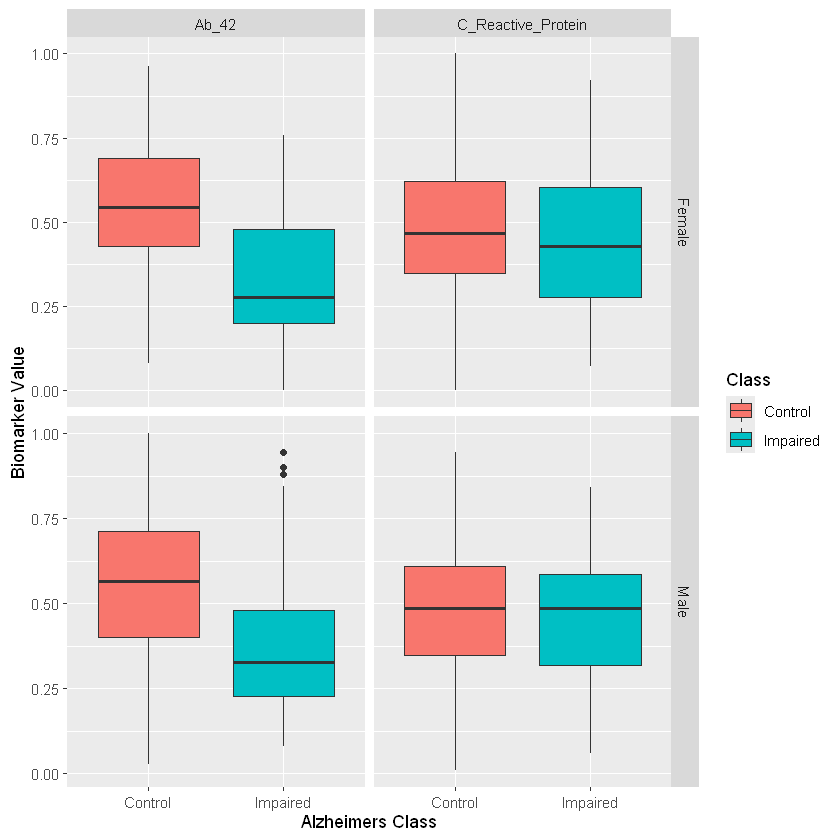

In [9]:
# Main Devleoper: Adam Walmsley

ggplot(plotting_data, aes(x = Class, y = Value, fill = Class)) +
    geom_boxplot() +
    facet_grid(male ~ Biomarker, scales = 'free_y') +
    labs(Title = 'Top 2 Biomarker by Variance', 
        x = 'Alzheimers Class',
        y = 'Biomarker Value')

From the plot above the values of the biomarker Ab_42 clearly show a difference in the Class of the patients. Gender less so. Also c_Reactive_protein seems much less promising as a useful predictor of class. This is a promising result nonetheless since we have confirmed the amounts of the values of some biomarkers likely will help us in predicting the class of patients and thus variable selection methods can be analyzed further. 

To further explore the data, we examine potential multicollinearity among biomarkers using a correlation heatmap. Since the dataset contains a large number of variables, we restrict our focus to the top 10 biomarkers with the highest variance, as these are more likely to be informative. By visualizing the correlations between these variables, we can assess whether strong relationships exist that may indicate multicollinearity, which could affect model stability and variable selection methods.

In [10]:
# Main Developer: An Trinh

top10_var <- dataset |>
  dplyr::select(where(is.numeric), -age) |>
  summarise(across(everything(), var)) |>
  unlist() |>
  sort(decreasing = TRUE) |>
  head(10) |>
  names()

top10_var

[1] "Ab_42"                            "C_Reactive_Protein"              
 [3] "Angiotensinogen"                  "tau"                             
 [5] "Fetuin_A"                         "IL_6_Receptor"                   
 [7] "CgA"                              "IL_11"                           
 [9] "IL_4"                             "Pulmonary_and_Activation_Regulat"

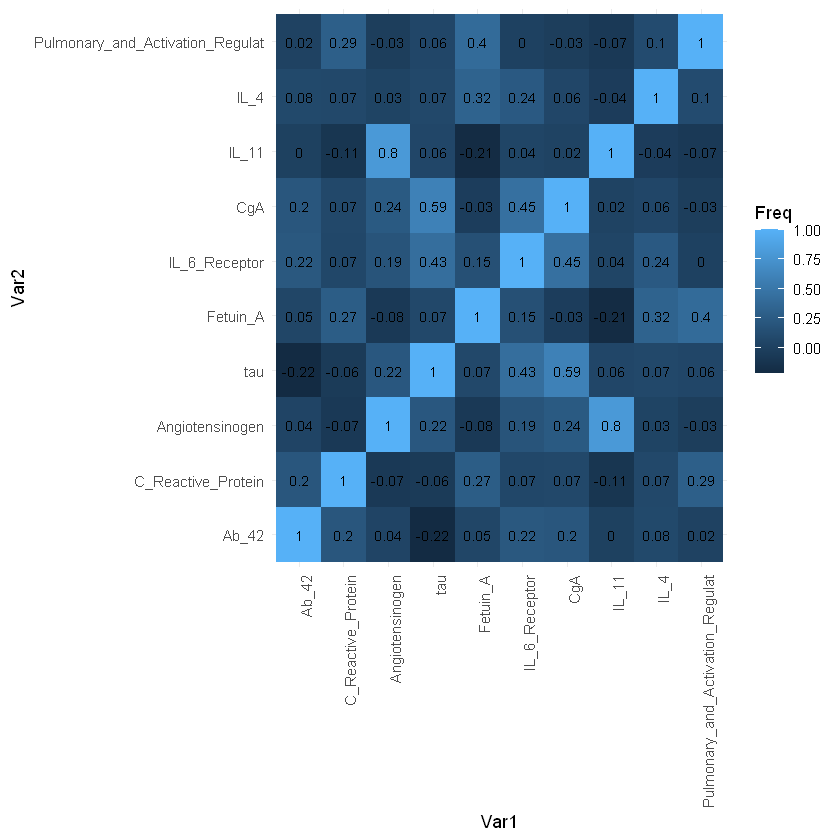

In [11]:
# Main Developer: An Trinh

cor_mat <- cor(dataset[, top10_var], use = "complete.obs")
cor_df <- as.data.frame(as.table(cor_mat))

ggplot(cor_df, aes(Var1, Var2, fill = Freq)) +
  geom_tile() +
  theme_minimal() +
  geom_text(aes(label = round(Freq, 2)), size = 3) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))

The correlation heatmap shows that while most biomarkers are only weakly to moderately correlated, there are some strong relationships (correlation between IL_11 and Angiotensinogen = 0.8), indicating the presence of multicollinearity among certain variables. This suggests that some predictors may provide overlapping information, which could affect model stability and supports the use of regularization methods.

#### Methods: Plan

**Data Splitting**

To evaluate model performance, we partitioned the data into a training set (70%) and a test set (30%). While standard practice often utilizes a three way split (training, validation, and testing) to ensure the test set is strictly used for final assessment, our dataset is severely constrained with only 333 observations. Allocating data to a third validation set would reduce the statistical power of the training set, risking underfitted models that fail to capture meaningful biological signals. Therefore, we rely on a two way split here.

**Model Training**

Using the training set, we will fit three separate models to handle the high dimensionality of our biomarker data:

- Stepwise Logistic Regression: This model will iteratively add predictors based on AIC.

- Lasso and Ridge Logistic Regression: To fit these regularized models, we will use 5-fold cross validation with the training set to identify the optimal penalty parameter (λ). This tuning ensures the models apply the correct amount of shrinkage. Lasso will allow for variable selection by shrinking less influential coefficients to zero, whereas Ridge will retain all variables but minimize their magnitudes.

**Model Comparison and Selection**

Once trained, the three candidate models will be evaluated on the independent test set. Due to the imbalanced nature of the response variable, relying on accuracy alone is insufficient. Therefore, we will compare the models based on Area Under the ROC Curve (AUC), F1 score, sensitivity, specificity, precision, and accuracy. The final "best" model will be selected based on performance across these test set metrics, while also considering model complexity (the number of variables retained) to ensure clinical usability.

**Final Interpretation**

Following selection, we will discuss whether the best performing model is suitable for clinical use.

**Splitting The Data**

In [12]:
# Main Developer: Aadetri Tawara

set.seed(42)

# Split the data into 30% test and 70% training sets
# Stratifying by response variable because of class imbalance
data_split <- initial_split(dataset, prop = 0.70, strata = Class)
train_data <- training(data_split)
test_data  <- testing(data_split)

**Lasso Logistic Regression:**

In [13]:
# Main Developer: Aadetri Tawara

# Extract explanatory and response variables matrix
x_train <- model.matrix(Class ~ ., data = train_data)[, -1] 
y_train <- as.matrix(train_data$Class, ncol = 1)

x_test <- model.matrix(Class ~ ., data = test_data)[, -1] 
y_test <- as.matrix(test_data$Class, ncol = 1)

# Select lambda (lasso regularization coefficient) using 5 fold cross validation
cv_lasso <- cv.glmnet(x_train, y_train, 
                    family = "binomial", # binary response variable
                    alpha = 1,           # lasso regularization
                    nfolds = 5, 
                    type.measure = "auc")

# LASSO coefficients for the 1se lambda
coef_1se <- coef(cv_lasso, s = "lambda.1se")

# LASSO coefficients for min lambda value
coef_min <- coef(cv_lasso, s = "lambda.min")

In [14]:
# Main Developer: Aadetri Tawara

# Function to extract only non zero variables
get_nonzero <- function(coef_matrix) {
  df <- as.matrix(coef_matrix)
  # Filter for rows not equal to 0
  nonzero <- df[df[, 1] != 0, , drop = FALSE]
  return(nonzero)
}

cat("Min Lambda\n")
print(get_nonzero(coef_min))
cat("\n1se Lambda\n")
print(get_nonzero(coef_1se))

Min Lambda
                                  lambda.min
(Intercept)                      -6.84508356
Alpha_2_Macroglobulin            -3.70550251
Apolipoprotein_B                  0.36747840
C_Reactive_Protein                0.12961856
CgA                              -0.09686285
Clusterin_Apo_J                   0.56457026
Connective_Tissue_Growth_Factor   0.38088894
Cortisol                          1.17922878
Cystatin_C                       -2.97433241
EN_RAGE                          -1.02178206
ENA_78                           -1.57942845
FSH_Follicle_Stimulation_Hormon  -0.11015893
Fibrinogen                        1.28939133
GRO_alpha                         0.29274956
Gamma_Interferon_induced_Monokin  1.77894630
IGF_BP_2                          1.23706008
IL_5                             -0.64901923
IL_7                             -0.39884506
Kidney_Injury_Molecule_1_KIM_1    0.43651915
Leptin                            1.47312007
MCP_2                             0.78318270

Based on the final selected models displayed above, the 1se lambda model is going to be selected for the final analysis because it provides a more parsimonious set of predictors while maintaining alignment with established Alzheimer's literature (specifically regarding `tau` and `ab_42`).

In [15]:
# Main Developer: Aadetri Tawara

# Test set prediction probabilities
pred_probs <- predict(
    cv_lasso, 
    newx = x_test,
    type = "response",
    s = "lambda.1se" # simpler model's lambda selected
)

# Converting probabilities to classes
pred_class <- ifelse(pred_probs > 0.5, "Impaired", "Control")

raw_preds  <- as.vector(pred_class)
raw_actual <- as.vector(y_test)

# Convert to factor
target_levels <- c("Control", "Impaired") 
pred_fact   <- factor(raw_preds,  levels = target_levels)
actual_fact <- factor(raw_actual, levels = target_levels)

# Confusion matrix
conf_results <- confusionMatrix(pred_fact, actual_fact, positive = "Impaired")


In [16]:
# Main Developer: Aadetri Tawara

# Extracting performance metrics from confusion matrix
accuracy    <- conf_results$overall["Accuracy"]
sensitivity <- conf_results$byClass["Sensitivity"]
specificity <- conf_results$byClass["Specificity"]
precision   <- conf_results$byClass["Precision"]
f1_score    <- conf_results$byClass["F1"]

# Extracting AUC from glmnet for lambda.1se
lambda_idx <- which(cv_lasso$lambda == cv_lasso$lambda.1se)
auc_score <- cv_lasso$cvm[lambda_idx]

# Putting metrics in a table
lasso_metrics_table <- data.frame(
    Model = "Lasso",
    Metric = c("Accuracy", "Specificity", "Sensitivity", "Precision", "F1 Score", "AUC"),
    Value = c(accuracy, specificity, sensitivity, precision, f1_score, auc_score),
    row.names = NULL 
)

Next we will repeat this process using Ridge and stepwise variable selection.

**Ridge Logistic Regression:**

In [17]:
# Main Developer: Kenrick Tan

cv_ridge <- cv.glmnet(
  x_train, y_train,
  family = "binomial",   # binary response
  alpha = 0,             # ridge regularization
  nfolds = 5,
  type.measure = "auc"
)

# Coefficients for lambda.min and lambda.1se
ridge_coef_min <- coef(cv_ridge, s = "lambda.min")
ridge_coef_1se <- coef(cv_ridge, s = "lambda.1se")

In [18]:
# Main Developer: Kenrick Tan

# Test set prediction probabilities
ridge_probs <- predict(
  cv_ridge,
  newx = x_test,
  type = "response",
  s = "lambda.1se"
)

# Convert probabilities to classes
ridge_pred_class <- ifelse(ridge_probs > 0.5, "Impaired", "Control")

ridge_raw_preds  <- as.vector(ridge_pred_class)
ridge_raw_actual <- as.vector(y_test)

# Convert to factor
target_levels <- c("Control", "Impaired")
ridge_pred_fact   <- factor(ridge_raw_preds, levels = target_levels)
ridge_actual_fact <- factor(ridge_raw_actual, levels = target_levels)

# Confusion matrix
ridge_conf_results <- confusionMatrix(
  ridge_pred_fact,
  ridge_actual_fact,
  positive = "Impaired"
)

In [19]:
# Main Developer: Kenrick Tan

ridge_accuracy    <- ridge_conf_results$overall["Accuracy"]
ridge_sensitivity <- ridge_conf_results$byClass["Sensitivity"]
ridge_specificity <- ridge_conf_results$byClass["Specificity"]
ridge_precision   <- ridge_conf_results$byClass["Precision"]
ridge_f1_score    <- ridge_conf_results$byClass["F1"]

# Extract AUC from glmnet 
ridge_lambda_idx <- which(cv_ridge$lambda == cv_ridge$lambda.1se)
ridge_auc_score <- cv_ridge$cvm[ridge_lambda_idx]

# Put the metrics into a table
ridge_metrics_table <- data.frame(
  Model = "Ridge",
  Metric = c("Accuracy", "Specificity", "Sensitivity", "Precision", "F1 Score", "AUC"),
  Value = c(
    ridge_accuracy,
    ridge_specificity,
    ridge_sensitivity,
    ridge_precision,
    ridge_f1_score,
    ridge_auc_score
  ),
    row.names = NULL
)

**Logistic Regression with stepwise variable selection:**


In [20]:
# Main Developer: An Trinh
# Contributors: Aadetri Tawara (changed to forward selection for faster runtime)

# Fit null & full model using all predictors
null_model <- glm(Class ~ 1, data = train_data, family = "binomial")
full_model <- glm(Class ~ ., data = train_data, family = "binomial")

# Limit steps in favor of runtime

suppressWarnings({
  capture.output(step_model <- stepAIC(
    null_model, 
    direction = "forward", 
    scope = list(lower = null_model, upper = full_model),
    trace = FALSE))
})

# Check convergence
step_model$converged

Warning message:
"glm.fit: algorithm did not converge"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"


character(0)

[1] FALSE

In [21]:
# Main Developer: An Trinh

# Get the variable selected from final stepwise model
get_selected_vars <- function(model) {
  vars <- names(coef(model))
  # remove intercept
  vars <- vars[vars != "(Intercept)"]
  return(vars)
}

cat("Selected Variables (Stepwise):\n")
print(get_selected_vars(step_model))

Selected Variables (Stepwise):
 [1] "tau"                              "Cystatin_C"                      
 [3] "PAI_1"                            "Alpha_2_Macroglobulin"           
 [5] "Clusterin_Apo_J"                  "VEGF"                            
 [7] "Thymus_Expressed_Chemokine_TECK"  "Connective_Tissue_Growth_Factor" 
 [9] "Gamma_Interferon_induced_Monokin" "ENA_78"                          
[11] "Leptin"                           "ACE_CD143_Angiotensin_Converti"  
[13] "EN_RAGE"                          "Hepatocyte_Growth_Factor_HGF"    
[15] "Betacellulin"                    


In [22]:
# Main Developer: An Trinh

# Predict probabilities on test set
step_probs <- predict(
  step_model,
  newdata = test_data,
  type = "response"
)

# Threshold = 0.5
step_pred_class <- ifelse(step_probs > 0.5, "Impaired", "Control")

# Convert to vectors
step_raw_preds  <- as.vector(step_pred_class)
step_raw_actual <- as.vector(test_data$Class)

# Convert to factors for evaluation
target_levels <- c("Control", "Impaired")
step_pred_fact   <- factor(step_raw_preds,  levels = target_levels)
step_actual_fact <- factor(step_raw_actual, levels = target_levels)


# Confusion matrix
step_conf_results <- confusionMatrix(
  step_pred_fact,
  step_actual_fact,
  positive = "Impaired"
)

In [23]:
# Main Developer: An Trinh

step_accuracy    <- step_conf_results$overall["Accuracy"]
step_sensitivity <- step_conf_results$byClass["Sensitivity"]
step_specificity <- step_conf_results$byClass["Specificity"]
step_precision   <- step_conf_results$byClass["Precision"]
step_f1_score    <- step_conf_results$byClass["F1"]


# Compute AUC on test set
step_roc_obj <- roc(actual_fact, as.vector(step_probs))
step_auc_test <- auc(step_roc_obj)


# Combine metrics into table

step_metrics_table <- data.frame(
  Model = "Stepwise",
  Metric = c("Accuracy", "Specificity", "Sensitivity", "Precision", "F1 Score", "AUC"),
  Value = c(step_accuracy, step_specificity, step_sensitivity, step_precision, step_f1_score, step_auc_test),
  row.names = NULL
)

Setting levels: control = Control, case = Impaired

Setting direction: controls < cases



**All Models Summary**

In [24]:
# Main Developer: Aadetri Tawara

# Combine all metrics into one table
all_metrics <- rbind(lasso_metrics_table, ridge_metrics_table, step_metrics_table)

# Converting to wider format for better readability
all_metrics <- all_metrics |>
    pivot_wider(names_from = Metric, values_from = Value)
    
all_metrics

Model,Accuracy,Specificity,Sensitivity,Precision,F1 Score,AUC
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Lasso,0.7623762,0.9589041,0.2500000,0.7000000,0.3684211,0.9295171
Ridge,0.7524752,0.9726027,0.1785714,0.7142857,0.2857143,0.9067787
Stepwise,0.7128713,0.8356164,0.3928571,0.4782609,0.4313725,0.6262231


## Discussion


From the results above, it appears as though Lasso performed best in terms of accuracy, F1 score, and AUC. Meanwhile Ridge performed best in specificity and precision. Finally, stepwise variable selection performed best in sensitivity. 

In a clinical context, the most important metric is sensitivity (the ability to detect true positives, which in this case is cognitive impairment). This suggests the stepwise algorithm selected the best model. However, while stepwise has the highest sensitivity, it also has the lowest precision out of the three models. This is concerning as it suggests the model is likely producing many false positives, flagging patients as having cognitive impairment even when they actually don’t. 

Another potential limitation of the stepwise model is its mathematical instability during the selection process. The model did not converge, which is likely due to the high dimensionality of the dataset (131 variables) relative to the sample size (333 observations), which increases the risk of overfitting. Warning messages (“algorithm did not converge” and “fitted probabilities numerically 0 or 1 occurred”) indicate separation, where combinations of predictors perfectly classify the outcome. As a result, the final selected variables become less reliable, leading to the final model being unstable.

The ridge regression model is also not very useful as it has the lowest sensitivity out of the three models. This may be due to the fact that this regularization technique only shrinks the regression coefficients toward zero, but it does not set them exactly to zero, preventing actual variable selection from occurring. Therefore, the final model is trained on 131 variables, making it highly prone to overfitting and resulting in low out of sample performance as seen in our output.

A model that performs slightly worse in sensitivity than the stepwise model, but much better in precision and AUC, is Lasso. This model also contains a small subset of the original 131 variables, making it more parsimonious while still performing better than the others overall.

However, even though lasso regression performs best overall, it is only able to identify ~32% of true positive cases, which is not very informative or useful for use in a clinical setting. This suggests that none of our fitted models are fully ready for clinical deployment.


Our original hypothesis was largely supported; the most promising models for isolating key predictive biomarkers were those that reduced dimensionality the most: stepwise and lasso. Additionally, the best performing model, lasso, selected the following variables: Cystatin_C, GRO_alpha, Gamma_Interferon_induced_Monokin, NT_proBNP, PAI_1, Thymus_Expressed_Chemokine_TECK, VEGF, Tau, and Ab_42. As originally hypothesized, tau and ab_42 were among the selected variables, suggesting our model aligns with previous literature in the field. However, none of the fitted models are currently deployable for clinical use and Alzheimer's diagnosis yet due to low sensitivity. 

Our methodology has a few notable limitations. First, by using the test set to select the best of our three models, we introduced a degree of data leakage; our final performance estimates may be overly optimistic because the test data directly influenced our final decision. Second, our limited sample size makes the models more susceptible to capturing noise rather than true patterns. Thirdly, the fact that the dataset is primarily observational means that we cannot draw any causal relationships from this. This however is something which can be researched further in the future.

Our modeling approach relies on the assumption of linearity between the predictor variables and the log-odds of the response. Each observation is also assumed to be independent of each other.

All models could be further improved by maximizing sensitivity to align with the clinical objective. While a classification threshold of 0.5 provides a consistent baseline across models, adjusting this threshold could improve sensitivity and prioritize the detection of positive cases. Additionally, the models were tuned using AUC, which captures overall performance, but does not directly prioritize sensitivity. Incorporating evaluation metrics such as sensitivity or F1-score during model selection, along with techniques to address potential class imbalance for the response variable and important predictors, may further enhance model performance and clinical usefulness.

Future research could focus on increasing the sample size to improve the stability of variable selection and reduce overfitting. Incorporating temporal data, where biomarkers are measured over time, may also provide more informative features and improve variables selection as well as overall model's performance. Finally, integrating domain knowledge and working with professionals in medical fields may guide variable selection and result in more interpretable and clinically meaningful models.


## References

Goerdten, Jantje, et al. “Statistical methods for dementia risk prediction and recommendations for future work: A systematic review.” Alzheimer’s &amp; Dementia: Translational Research &amp; Clinical Interventions, vol. 5, no. 1, Jan. 2019, pp. 563–569, https://doi.org/10.1016/j.trci.2019.08.001. 

Subramanian, Jyothi, and Richard Simon. “Overfitting in prediction models – is it a problem only in high dimensions?” Contemporary Clinical Trials, vol. 36, no. 2, Nov. 2013, pp. 636–641, https://doi.org/10.1016/j.cct.2013.06.011. 

Iaccarino, Leonardo, et al. “Diagnostic biomarkers of amyloid and tau pathology in alzheimer’s disease: An overview of tests for clinical practice in the United States and Europe.” The Journal of Prevention of Alzheimer’s Disease, vol. 10, no. 3, Sept. 2023, pp. 426–442, https://doi.org/10.14283/jpad.2023.43. 

Craig-Schapiro, Rebecca, et al. “Multiplexed immunoassay panel identifies novel CSF biomarkers for alzheimer’s disease diagnosis and prognosis.” PLoS ONE, vol. 6, no. 4, 19 Apr. 2011, https://doi.org/10.1371/journal.pone.0018850. 